In [2]:
# python═══════════════════════════════════════
# CELL 1 — Libraries
# ═══════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
print("✅ Libraries ready!")

✅ Libraries ready!


In [3]:
# ═══════════════════════════════════════
# CELL 2 — Load & Rename
# ═══════════════════════════════════════
df = pd.read_csv(r"C:\Users\Satish\.anaconda\Leads.csv.csv")
df = df.rename(columns={
    'Lead Number'                    : 'lead_id',
    'Lead Source'                    : 'source',
    'Converted'                      : 'enrolled',
    'Specialization'                 : 'course',
    'City'                           : 'city',
    'TotalVisits'                    : 'total_visits',
    'Total Time Spent on Website'    : 'time_on_site',
    'Lead Quality'                   : 'lead_quality',
    'Last Activity'                  : 'last_activity',
    'What is your current occupation': 'occupation',
    'Country'                        : 'country',
})
print(f"✅ Rows loaded: {len(df)}")  # must show 9,240

✅ Rows loaded: 9240


In [4]:
# ═══════════════════════════════════════
# CELL 3 — Create called column
# ═══════════════════════════════════════
df['called'] = df['last_activity'].isin([
    'SMS Sent', 'Email Sent', 'Phone Called',
    'Olark Chat Conversation', 'Email Opened',
    'Email Link Clicked'
])
print("✅ called column created!")
print(df['called'].value_counts())


✅ called column created!
called
True     7422
False    1818
Name: count, dtype: int64


In [5]:
# ═══════════════════════════════════════
# CELL 4 — Lead Score
# ═══════════════════════════════════════
df['visits_score'] = (df['total_visits'].clip(0,10)/10*30).fillna(0)
df['time_score']   = (df['time_on_site'].clip(0,3000)/3000*30).fillna(0)
df['source_score'] = df['source'].apply(
    lambda x: 20 if x in ['Organic Search','Google','Referral'] else 0)
df['occ_score']    = df['occupation'].apply(
    lambda x: 20 if x == 'Working Professional' else 0)
df['lead_score'] = (
    df['visits_score'] + df['time_score'] +
    df['source_score'] + df['occ_score']
).round(1)
print("✅ lead_score created!")
print(df['lead_score'].describe().round(1))

✅ lead_score created!
count    9240.0
mean       24.5
std        18.9
min         0.0
25%         6.8
50%        26.2
75%        38.9
max        90.7
Name: lead_score, dtype: float64


In [6]:
# ═══════════════════════════════════════
# CELL 5 — Priority Buckets
# ═══════════════════════════════════════
df['priority'] = pd.cut(
    df['lead_score'],
    bins=[-1, 30, 50, 100],
    labels=['Low', 'Medium', 'High']
)
print("✅ Priority created!")
print(df['priority'].value_counts())


✅ Priority created!
priority
Low       5279
Medium    3149
High       812
Name: count, dtype: int64


In [7]:
# ═══════════════════════════════════════
# CELL 6 — 4 Stage Funnel
# ═══════════════════════════════════════
total       = len(df)
crm_entered = df['lead_quality'].notna().sum()
contacted   = df['called'].sum()
enrolled    = df['enrolled'].sum()

print("======= 4-STAGE FUNNEL — MIT SDE =======")
print(f"Stage 1 | Total Leads : {total:,}         (100%)")
print(f"Stage 2 | CRM Entry   : {crm_entered:,}   ({crm_entered/total*100:.1f}%)")
print(f"Stage 3 | Contacted   : {contacted:,}   ({contacted/total*100:.1f}%)")
print(f"Stage 4 | Enrolled    : {enrolled:,}   ({enrolled/total*100:.1f}%)")
print("=========================================")
print("\n===== DROP-OFF ANALYSIS =====")
print(f"Never entered CRM  : {total-crm_entered:,} leads lost")
print(f"In CRM not called  : {crm_entered-contacted:,} leads lost")
print(f"Called not enrolled: {contacted-enrolled:,} leads lost")


======= 4-STAGE FUNNEL — MIT SDE =======
Stage 1 | Total Leads : 9,240         (100%)
Stage 2 | CRM Entry   : 4,473   (48.4%)
Stage 3 | Contacted   : 7,422   (80.3%)
Stage 4 | Enrolled    : 3,561   (38.5%)

===== DROP-OFF ANALYSIS =====
Never entered CRM  : 4,767 leads lost
In CRM not called  : -2,949 leads lost
Called not enrolled: 3,861 leads lost


In [8]:
# ═══════════════════════════════════════
# CELL 5 — Priority Buckets
# ═══════════════════════════════════════
df['priority'] = pd.cut(
    df['lead_score'],
    bins=[-1, 30, 50, 100],
    labels=['Low', 'Medium', 'High']
)
print("✅ Priority created!")
print(df['priority'].value_counts())


✅ Priority created!
priority
Low       5279
Medium    3149
High       812
Name: count, dtype: int64


In [9]:
# ═══════════════════════════════════════
# CELL 6 — 4 Stage Funnel
# ═══════════════════════════════════════
total       = len(df)
crm_entered = df['lead_quality'].notna().sum()
contacted   = df['called'].sum()
enrolled    = df['enrolled'].sum()

print("======= 4-STAGE FUNNEL — MIT SDE =======")
print(f"Stage 1 | Total Leads : {total:,}         (100%)")
print(f"Stage 2 | CRM Entry   : {crm_entered:,}   ({crm_entered/total*100:.1f}%)")
print(f"Stage 3 | Contacted   : {contacted:,}   ({contacted/total*100:.1f}%)")
print(f"Stage 4 | Enrolled    : {enrolled:,}   ({enrolled/total*100:.1f}%)")
print("=========================================")
print("\n===== DROP-OFF ANALYSIS =====")
print(f"Never entered CRM  : {total-crm_entered:,} leads lost")
print(f"In CRM not called  : {crm_entered-contacted:,} leads lost")
print(f"Called not enrolled: {contacted-enrolled:,} leads lost")


======= 4-STAGE FUNNEL — MIT SDE =======
Stage 1 | Total Leads : 9,240         (100%)
Stage 2 | CRM Entry   : 4,473   (48.4%)
Stage 3 | Contacted   : 7,422   (80.3%)
Stage 4 | Enrolled    : 3,561   (38.5%)

===== DROP-OFF ANALYSIS =====
Never entered CRM  : 4,767 leads lost
In CRM not called  : -2,949 leads lost
Called not enrolled: 3,861 leads lost


In [10]:
# ═══════════════════════════════════════
# CELL 7 — Channel Performance
# ═══════════════════════════════════════
top_sources = df['source'].value_counts().head(5).index.tolist()
df['source_clean'] = df['source'].apply(
    lambda x: x if x in top_sources else 'Other')

channel_stats = df.groupby('source_clean').agg(
    total_leads = ('lead_id', 'count'),
    total_enrol = ('enrolled', 'sum')
).reset_index()
channel_stats['conv_rate'] = (
    channel_stats['total_enrol'] /
    channel_stats['total_leads'] * 100
).round(1)
channel_stats = channel_stats.sort_values(
    'conv_rate', ascending=False).reset_index(drop=True)
print(channel_stats.to_string(index=False))


  source_clean  total_leads  total_enrol  conv_rate
     Reference          534          490       91.8
         Other          386          222       57.5
        Google         2868         1147       40.0
Organic Search         1154          436       37.8
Direct Traffic         2543          818       32.2
    Olark Chat         1755          448       25.5


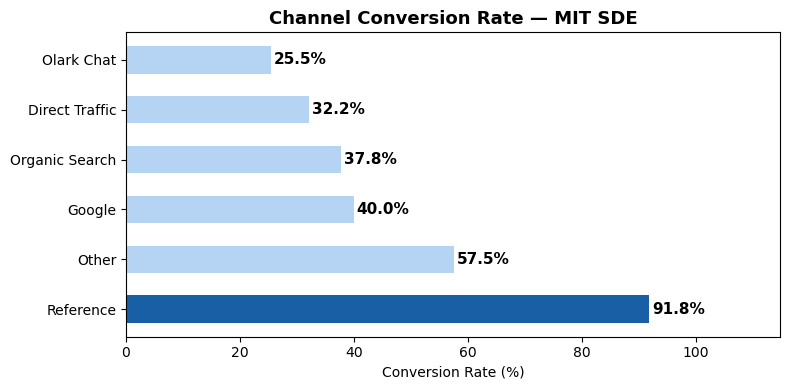

In [12]:
# Bar Chart
colors = ['#185FA5' if v == channel_stats['conv_rate'].max()
          else '#B5D4F4' for v in channel_stats['conv_rate']]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(channel_stats['source_clean'],
               channel_stats['conv_rate'],
               color=colors, height=0.55)
for bar, val in zip(bars, channel_stats['conv_rate']):
    ax.text(bar.get_width()+0.5,
            bar.get_y()+bar.get_height()/2,
            f'{val}%', va='center',
            fontsize=11, fontweight='bold')
ax.set_xlabel('Conversion Rate (%)')
ax.set_title('Channel Conversion Rate — MIT SDE',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, channel_stats['conv_rate'].max()*1.25)
plt.tight_layout()
plt.show()


In [13]:
# ═══════════════════════════════════════
# CELL 8 — Top 10 High Priority Leads
# ═══════════════════════════════════════
top_10 = df[df['priority'] == 'High']\
    .sort_values('lead_score', ascending=False)\
    .head(10)
print("TOP 10 LEADS — CALL THESE FIRST:")
print(top_10[[
    'lead_id', 'source',
    'city', 'occupation', 'lead_score'
]].to_string(index=False))


TOP 10 LEADS — CALL THESE FIRST:
 lead_id         source                        city           occupation  lead_score
  651807         Google                      Mumbai Working Professional        90.7
  580595         Google                      Mumbai Working Professional        88.5
  589305         Google                      Mumbai Working Professional        88.4
  606508 Organic Search                      Select Working Professional        88.2
  601618         Google                      Mumbai Working Professional        87.0
  646366 Organic Search                      Mumbai Working Professional        85.7
  635018         Google                      Select Working Professional        85.1
  611863 Organic Search                      Select Working Professional        84.9
  589544 Organic Search Other Cities of Maharashtra Working Professional        84.4
  607531 Organic Search           Thane & Outskirts Working Professional        83.8


In [14]:
# ═══════════════════════════════════════
# CELL 9 — Final Weekly Report
# ═══════════════════════════════════════
high_pri = (df['priority'] == 'High').sum()

print("===== WEEKLY REPORT — MIT SDE =====")
print(f"Total Leads   : {total:,}")
print(f"CRM Entry     : {crm_entered:,} ({crm_entered/total*100:.1f}%)")
print(f"Contacted     : {contacted:,} ({contacted/total*100:.1f}%)")
print(f"Enrolled      : {enrolled:,} ({enrolled/total*100:.1f}%)")
print(f"High Priority : {high_pri:,} leads")
print("====================================")


===== WEEKLY REPORT — MIT SDE =====
Total Leads   : 9,240
CRM Entry     : 4,473 (48.4%)
Contacted     : 7,422 (80.3%)
Enrolled      : 3,561 (38.5%)
High Priority : 812 leads


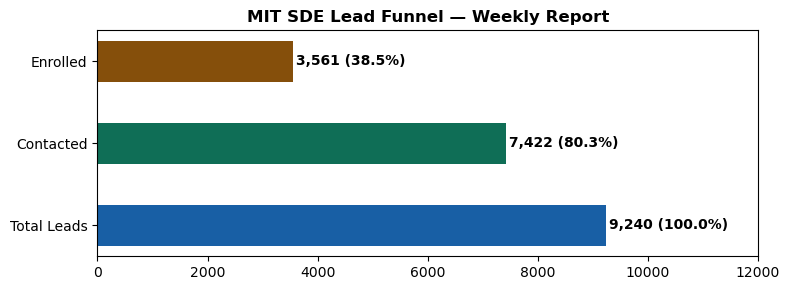

✅ Weekly report complete!


In [17]:
# Funnel Chart
stages = ['Total Leads', 'Contacted', 'Enrolled']
values = [total, contacted, enrolled]
plt.figure(figsize=(8,3))
bars = plt.barh(stages, values,
    color=['#185FA5','#0F6E56','#854F0B'], height=0.5)
for bar, val in zip(bars, values):
    pct = val/total*100
    plt.text(bar.get_width()+50,
             bar.get_y()+bar.get_height()/2,
             f'{val:,} ({pct:.1f}%)',
             va='center', fontweight='bold')
plt.title('MIT SDE Lead Funnel — Weekly Report',
          fontweight='bold')
plt.xlim(0, total*1.3)
plt.tight_layout()
plt.show()
print("✅ Weekly report complete!")


